In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

 The models we will be working with are : 
* ViT
* EfficeintV2
* ConvNext

1. Vision Transformer (ViT):
* Reason: ViT is a promising alternative to CNNs and has not been as extensively compared to traditional deepfake detection models. It leverages self-attention mechanisms instead of convolutional layers to analyze image patches.
* Unique Aspect: Provides insight into how transformer-based models fare against CNNs in detecting deepfakes.
2. EfficientNetV2:
* Reason: While EfficientNet (original) has been widely compared, EfficientNetV2 is an improved version with better training speed and accuracy. It’s relatively new and hasn’t been as extensively tested in deepfake detection research.
* Unique Aspect: Balances accuracy, efficiency, and faster training time, making it an interesting comparison.
3. ConvNeXT:
* Reason: ConvNeXT is a modern reinterpretation of traditional CNNs that incorporates design choices inspired by transformer models. It has shown competitive results in image classification and could provide a fresh take in deepfake detection.
* Unique Aspect: Brings a hybrid perspective that blends CNN architecture with recent advancements.
## Why This Combination?
* Innovation: ViT and ConvNeXT offer insights into how modern architectures (transformer-based or hybrid) compare against refined CNN designs.
* Balance: EfficientNetV2 represents an optimized CNN approach, while ViT and ConvNeXT push the boundaries of architectural design.
* Novelty: This combination of models has not been extensively compared in deepfake detection literature, making your research unique.

## EfficeintNetV2 B3

In [1]:
ls

In [2]:
# import tensorflow as tf

# # Reset the default graph
# tf.keras.backend.clear_session()
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

prep_train = ImageDataGenerator(preprocessing_function = preprocess_input,
                                   rotation_range=30, # the range of the rotation will be +30 degrees to -30 degrees
                                   width_shift_range=0.2, # the range of the  width shift will be 20% of its width
                                   height_shift_range=0.2, # the range of the  height shift will be 20% of its height
                                  #  shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True,)
prep_val = ImageDataGenerator(preprocessing_function = preprocess_input,
                                   rotation_range=30, # the range of the rotation will be +30 degrees to -30 degrees
                                   width_shift_range=0.2, # the range of the  width shift will be 20% of its width
                                   height_shift_range=0.2, # the range of the  height shift will be 20% of its height
                                  #  shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True,)

In [1]:
import tensorflow as tf
from tensorflow.keras import layers

# Load dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    '/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/train',
    # '/kaggle/working/train_n',
    labels='inferred',
    label_mode='binary',
    class_names=["fake","real"],
    color_mode='rgb',
    batch_size=32,
    image_size=(224, 224),
    shuffle=True
)
# train_dataset = prep_train.flow_from_directory(
#   '/kaggle/working/train_n',
#   target_size=(224,224),
#   batch_size=32,
#   class_mode='binary', 
#   shuffle=True
# )


Found 100000 files belonging to 2 classes.


In [1]:
import os
import shutil
import random

# Paths for original real and fake image folders
real_images_dir = '/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/train/real'
fake_images_dir = '/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/train/fake'


new_train_dir = '/kaggle/working/train_n'
new_real_dir = os.path.join(new_train_dir, 'real')
new_fake_dir = os.path.join(new_train_dir, 'fake')
os.makedirs(new_real_dir, exist_ok=True)
os.makedirs(new_fake_dir, exist_ok=True)
real_images = os.listdir(real_images_dir)
fake_images = os.listdir(fake_images_dir)

selected_real_images = random.sample(real_images, 1000)
selected_fake_images = random.sample(fake_images, 1000)

for img in selected_real_images:
    shutil.copy(os.path.join(real_images_dir, img), os.path.join(new_real_dir, img))

for img in selected_fake_images:
    shutil.copy(os.path.join(fake_images_dir, img), os.path.join(new_fake_dir, img))

print("Images copied successfully to 'train_new' directory!")

Images copied successfully to 'train_new' directory!


### New Validation Dir


In [2]:
import os
import shutil
import random


real_images_dir = '/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/valid/real'
fake_images_dir = '/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/valid/fake'


new_train_dir = '/kaggle/working/valid_n'
new_real_dir = os.path.join(new_train_dir, 'real')
new_fake_dir = os.path.join(new_train_dir, 'fake')


os.makedirs(new_real_dir, exist_ok=True)
os.makedirs(new_fake_dir, exist_ok=True)


real_images = os.listdir(real_images_dir)
fake_images = os.listdir(fake_images_dir)


selected_real_images = random.sample(real_images, 200)
selected_fake_images = random.sample(fake_images, 200)


for img in selected_real_images:
    shutil.copy(os.path.join(real_images_dir, img), os.path.join(new_real_dir, img))

for img in selected_fake_images:
    shutil.copy(os.path.join(fake_images_dir, img), os.path.join(new_fake_dir, img))

print("Images copied successfully to 'valid_new' directory!")


Images copied successfully to 'valid_new' directory!


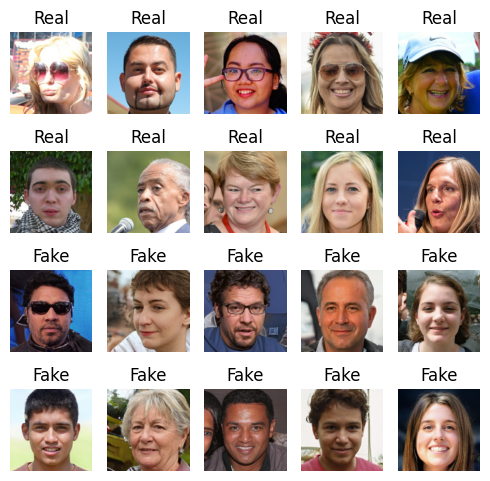

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import random

# Retrieve one batch from the dataset
images, labels = next(iter(train_dataset))

# Separate images into fake and real lists
fake_images = [img for img, label in zip(images, labels) if label == 0]
real_images = [img for img, label in zip(images, labels) if label == 1]

# Randomly select 10 images from each class
random_real_images = random.sample(real_images, 10)
random_fake_images = random.sample(fake_images, 10)

# Combine the selected images for visualization
selected_images = random_real_images + random_fake_images

# Plot the images in a grid (4 rows x 5 columns)
plt.figure(figsize=(5, 5))

for i in range(20):
    ax = plt.subplot(4, 5, i + 1)
    plt.imshow(selected_images[i].numpy().astype("uint8"))  # Convert to NumPy array and cast to uint8
    plt.axis("off")
    
    # Set titles for the first two rows as "Real" and the last two as "Fake"
    if i < 10:
        plt.title("Real")
    else:
        plt.title("Fake")

plt.tight_layout()
plt.show()



In [3]:
# Load validation dataset
val_dataset = tf.keras.utils.image_dataset_from_directory(
    '/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/valid',
    # '/kaggle/working/valid_n',
    labels='inferred',
    label_mode='binary',
    class_names=["fake", "real"],
    color_mode='rgb',
    batch_size=32,
    image_size=(224, 224),
    shuffle=False,
    seed=99,
)


# val_dataset = prep_val.flow_from_directory(
#     '/kaggle/working/valid_n',
#     target_size=(224, 224),
#     batch_size=32,
#     class_mode='binary', 
#     shuffle=True,      # Specify subset as validation
# )

Found 20000 files belonging to 2 classes.


### EfficientNetB4 Fine tuned Model (20 Layers)

In [4]:
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras import layers, models

In [5]:
import tensorflow as tf

base_model = EfficientNetB4(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model layers
for layer in base_model.layers:
    layer.trainable = False


x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(1024, activation='relu')(x)  # Intermediate dense layer
# x = layers.Dropout(0.5)(x)  # Dropout for regularization
# x = layers.Dense(512, activation='relu')(x)  # Additional intermediate dense layer
# x = layers.Dropout(0.4)(x)  # Additional dropout layer
# x = layers.Dense(256, activation='relu')(x)  # Additional intermediate dense layer
x = layers.Dropout(0.5)(x)  # Additional dropout layer
predictions = layers.Dense(1, activation='sigmoid')(x)  # Output layer for binary classification

model = Model(inputs=base_model.input, outputs=predictions)
for layer in base_model.layers[-20:]:
    layer.trainable = True

# Compile the model with binary crossentropy loss
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Print the model summary (optional)
# model.summary()

71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Epoch 1/20


I0000 00:00:1737216393.282894     102 service.cc:145] XLA service 0x7f0c640048b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1737216393.282970     102 service.cc:153]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0


   2/3125 ━━━━━━━━━━━━━━━━━━━━ 4:21 84ms/step - accuracy: 0.6016 - loss: 0.7142   

I0000 00:00:1737216453.552136     102 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


3125/3125 ━━━━━━━━━━━━━━━━━━━━ 377s 94ms/step - accuracy: 0.8319 - loss: 0.3743 - val_accuracy: 0.8927 - val_loss: 0.2571
Epoch 2/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 286s 91ms/step - accuracy: 0.9153 - loss: 0.2079 - val_accuracy: 0.9008 - val_loss: 0.2594
Epoch 3/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 285s 91ms/step - accuracy: 0.9358 - loss: 0.1624 - val_accuracy: 0.9488 - val_loss: 0.1359
Epoch 4/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 285s 91ms/step - accuracy: 0.9454 - loss: 0.1384 - val_accuracy: 0.9129 - val_loss: 0.2384
Epoch 5/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 285s 91ms/step - accuracy: 0.9540 - loss: 0.1193 - val_accuracy: 0.9563 - val_loss: 0.1219
Epoch 6/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 284s 91ms/step - accuracy: 0.9594 - loss: 0.1039 - val_accuracy: 0.9601 - val_loss: 0.1073
Epoch 7/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 283s 91ms/step - accuracy: 0.9631 - loss: 0.0967 - val_accuracy: 0.9481 - val_loss: 0.1495
Epoch 8/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 283s 91ms/step - accuracy: 0.9653 - lo

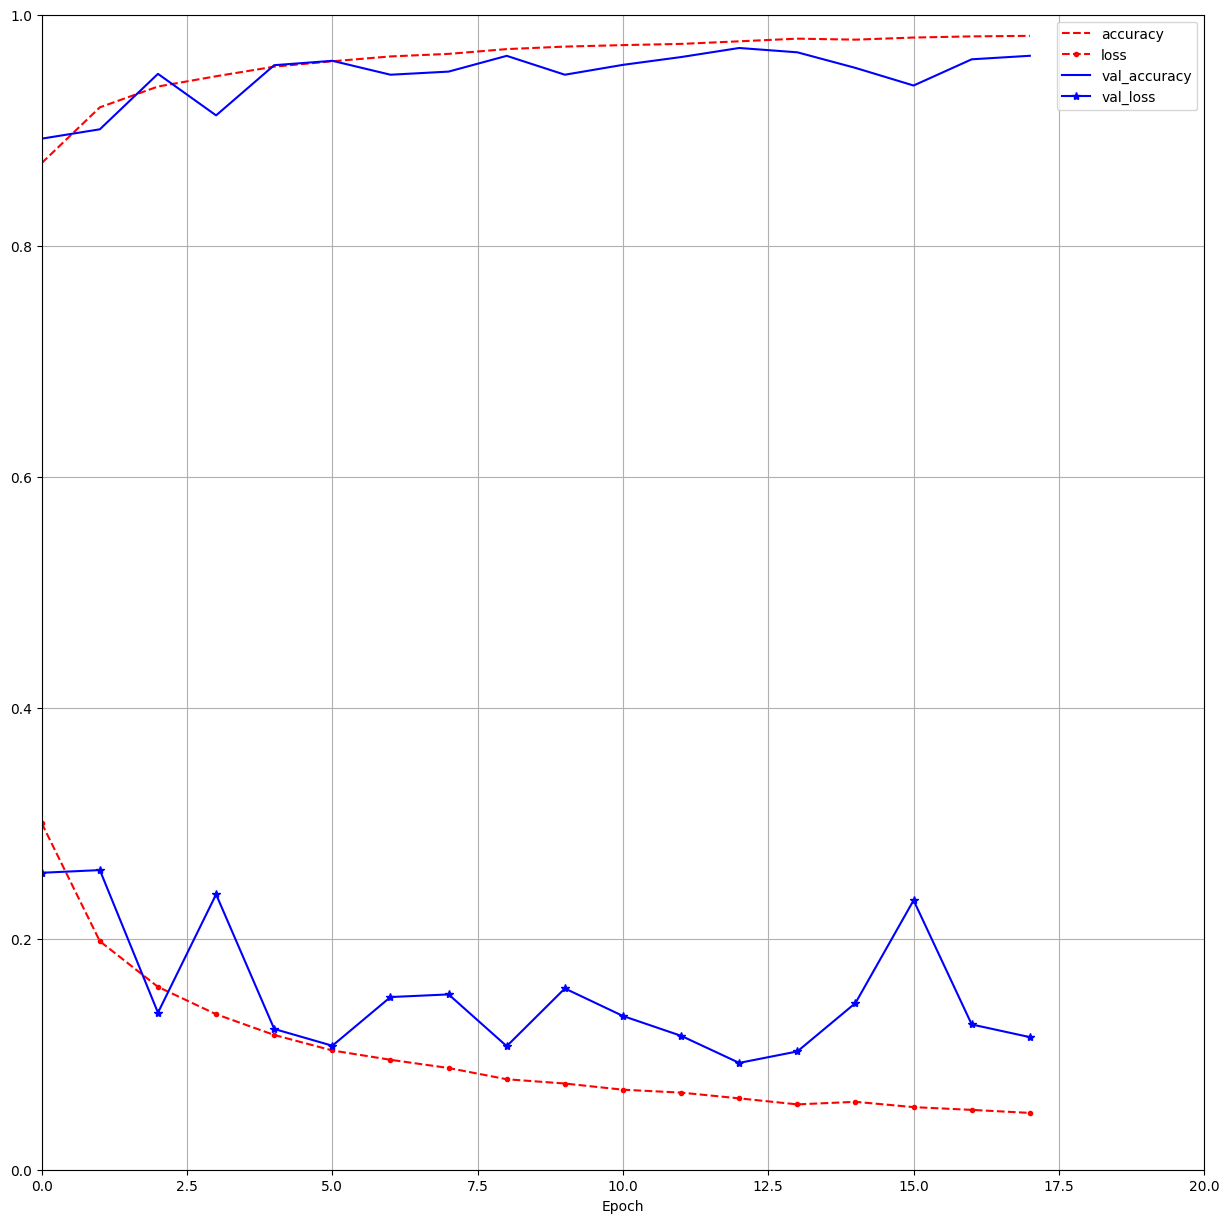

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_accuracy', 
    patience=5, 
    restore_best_weights=True  
)

history = model.fit(
    train_dataset,
    epochs=20,
    validation_data=val_dataset,
    callbacks=[early_stopping]
)

pd.DataFrame(history.history).plot(
figsize=(15, 15), xlim=[0, 20], ylim=[0, 1], grid=True, xlabel="Epoch",
style=["r--", "r--.", "b-", "b-*"])
plt.show()


In [ ]:
import os
import shutil
import random

# Paths for original real and fake image folders
real_images_dir = '/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/test/real'
fake_images_dir = '/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/test/fake'

# New directory to store the selected images
new_train_dir = '/kaggle/working/test_n'
new_real_dir = os.path.join(new_train_dir, 'real')
new_fake_dir = os.path.join(new_train_dir, 'fake')

# Create the new directories if they don't exist
os.makedirs(new_real_dir, exist_ok=True)
os.makedirs(new_fake_dir, exist_ok=True)

# Get the list of all image filenames in the original real and fake directories
real_images = os.listdir(real_images_dir)
fake_images = os.listdir(fake_images_dir)

# Select 10,000 random images from each class
selected_real_images = random.sample(real_images, 200)
selected_fake_images = random.sample(fake_images, 200)

# Copy the selected real images to the new real folder
for img in selected_real_images:
    shutil.copy(os.path.join(real_images_dir, img), os.path.join(new_real_dir, img))

# Copy the selected fake images to the new fake folder
for img in selected_fake_images:
    shutil.copy(os.path.join(fake_images_dir, img), os.path.join(new_fake_dir, img))

print("Images copied successfully to 'test_n' directory!")

In [ ]:
prep_test = ImageDataGenerator(
    preprocessing_function=preprocess_input, 
)
test_dataset = prep_val.flow_from_directory(
    '/kaggle/working/test_n',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',  
    shuffle=False 
)

In [ ]:
test_loss, test_accuracy = model.evaluate(test_dataset)

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Predict the labels for the test set
y_true = test_dataset.classes  # True labels
y_pred = model.predict(test_dataset)  # Model predictions (probabilities)

# Convert probabilities to class labels (0 or 1)
y_pred_classes = np.argmax(y_pred, axis=1)  # Get predicted class labels (0 or 1)

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plotting the confusion matrix
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
predicted_classes = tf.argmax(y_pred, axis=1)
print(predicted_classes)

In [ ]:
# act_classes = tf.argmax(test_dataset, axis=1)
print(y_true)

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

# Generate predictions
y_pred_probs = model.predict(test_dataset)
y_pred = np.where(y_pred_probs > 0.5, 1, 0).flatten()  

y_true = np.concatenate([y for x, y in test_dataset], axis=0)

precision_per_class = precision_score(y_true, y_pred, average=None)
recall_per_class = recall_score(y_true, y_pred, average=None)
f1_per_class = f1_score(y_true, y_pred, average=None)

print("\nPrecision for each class:", precision_per_class)
print("Recall for each class:", recall_per_class)
print("F1 Score for each class:", f1_per_class)

print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=["fake", "real"]))

### BAse Model for EffB4

In [13]:
# Load the EfficientNetB4 model, excluding the top layers
base_model = EfficientNetB4(weights='imagenet', include_top=False, input_shape=(224, 224, 3))


for layer in base_model.layers:
    layer.trainable = False


x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
predictions = layers.Dense(1, activation='sigmoid')(x) 

Bef_model = Model(inputs=base_model.input, outputs=predictions)


Bef_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Print the model summary (optional)
# model.summary()

In [ ]:
# base_history = Bef_model.fit(train_dataset, epochs=10, validation_data=val_dataset)
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_accuracy',  # or another metric you want to monitor
    patience=50,  # number of epochs to wait before stopping if no improvement
    restore_best_weights=True  # restore the best weights from the training
)

history = Bef_model.fit(
    train_dataset,
    epochs=25,  # set a large number of epochs as the upper bound
    validation_data=val_dataset,
    callbacks=[early_stopping]
)

pd.DataFrame(history.history).plot(
figsize=(8, 5), xlim=[0, 20], ylim=[0, 1], grid=True, xlabel="Epoch",
style=["r--", "r--.", "b-", "b-*"])
plt.show()

Epoch 1/25
  23/3125 ━━━━━━━━━━━━━━━━━━━━ 15:29:34 18s/step - accuracy: 0.6680 - loss: 0.6106

In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score


y_pred_probs = Bef_model.predict(test_dataset)  
y_pred = np.where(y_pred_probs > 0.5, 1, 0).flatten()  


y_true = np.concatenate([y for x, y in test_dataset], axis=0)


precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)


print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
